In [6]:
import sys
print(sys.executable)

c:\Users\LENOVO\anaconda3\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Levenshtein import editops
import os

In [8]:
# Config
DATA_PATH  = '../Data/IAM_OCR/iam_easyocr_final.csv'
OUTPUT_DIR = '../Outputs/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [9]:
# Load
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['ground_truth', 'ocr_output'])
df['ground_truth'] = df['ground_truth'].astype(str)
df['ocr_output']   = df['ocr_output'].astype(str)

print(f"Loaded {len(df)} samples")
print(f"Average CER: {df['cer'].mean():.4f}")

Loaded 10370 samples
Average CER: 0.5239


Character Level Error Extraction

In [10]:
substitutions = []
deletions     = []
insertions    = []

for i, row in df.iterrows():
    gt  = row['ground_truth'].lower()
    ocr = row['ocr_output'].lower()

    try:
        ops = editops(ocr, gt)
    except Exception:
        continue

    for op, src_idx, dst_idx in ops:
        if op == 'replace':
            src_char = ocr[src_idx] if src_idx < len(ocr) else ''
            dst_char = gt[dst_idx]  if dst_idx < len(gt)  else ''
            substitutions.append((src_char, dst_char))

        elif op == 'delete':
            src_char = ocr[src_idx] if src_idx < len(ocr) else ''
            deletions.append(src_char)

        elif op == 'insert':
            dst_char = gt[dst_idx] if dst_idx < len(gt) else ''
            insertions.append(dst_char)

print(f"Substitutions : {len(substitutions)}")
print(f"Deletions     : {len(deletions)}")
print(f"Insertions    : {len(insertions)}")
print(f"Total errors  : {len(substitutions) + len(deletions) + len(insertions)}")

Substitutions : 144097
Deletions     : 15811
Insertions    : 61910
Total errors  : 221818


Distribution of errors type

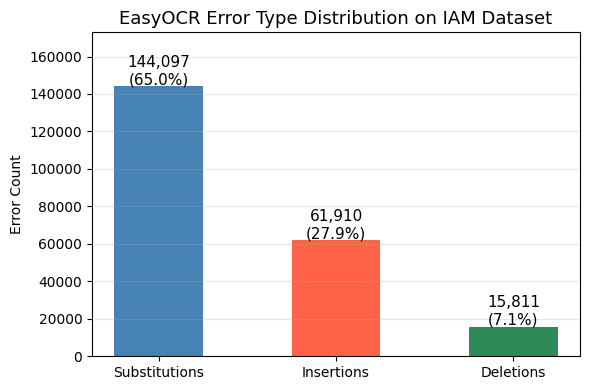

Saved


In [14]:
# Figure 1 — Error Type Distribution
error_counts = {
    'Substitutions': len(substitutions),
    'Insertions'   : len(insertions),
    'Deletions'    : len(deletions)
}

plt.figure(figsize=(6, 4))
bars = plt.bar(error_counts.keys(), error_counts.values(), 
               color=['steelblue', 'tomato', 'seagreen'], width=0.5)

for bar, val in zip(bars, error_counts.values()):
    pct = val / sum(error_counts.values()) * 100
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 1000,
             f'{val:,}\n({pct:.1f}%)', 
             ha='center', fontsize=11)

plt.title('EasyOCR Error Type Distribution on IAM Dataset', fontsize=13)
plt.ylabel('Error Count')
plt.ylim(0, max(error_counts.values()) * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/error_distribution.png', dpi=150)
plt.show()
print("Saved")

Top 20 Substitution pairs


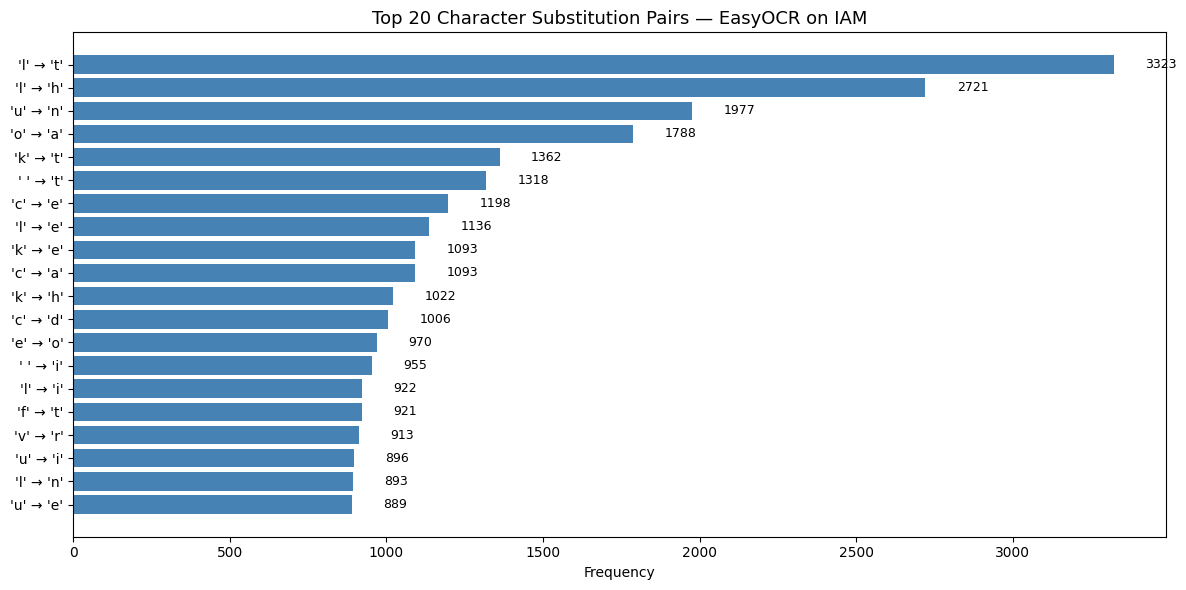


Top 10 substitutions:
  'l' misread as 't' : 3323 times
  'l' misread as 'h' : 2721 times
  'u' misread as 'n' : 1977 times
  'o' misread as 'a' : 1788 times
  'k' misread as 't' : 1362 times
  ' ' misread as 't' : 1318 times
  'c' misread as 'e' : 1198 times
  'l' misread as 'e' : 1136 times
  'k' misread as 'e' : 1093 times
  'c' misread as 'a' : 1093 times


In [15]:
from collections import Counter

# Count substitution pairs
sub_counts = Counter(substitutions)
top20_subs = sub_counts.most_common(20)

# Unpack
pairs  = [f"'{s}' → '{t}'" for s, t in [p[0] for p in top20_subs]]
counts = [p[1] for p in top20_subs]

plt.figure(figsize=(12, 6))
bars = plt.barh(pairs[::-1], counts[::-1], color='steelblue')

for bar, val in zip(bars, counts[::-1]):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

plt.title('Top 20 Character Substitution Pairs — EasyOCR on IAM', fontsize=13)
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/figures/top20_substitutions.png', dpi=150)
plt.show()

print("\nTop 10 substitutions:")
for (src, dst), count in top20_subs[:10]:
    print(f"  '{src}' misread as '{dst}' : {count} times")

CER distribution histogram

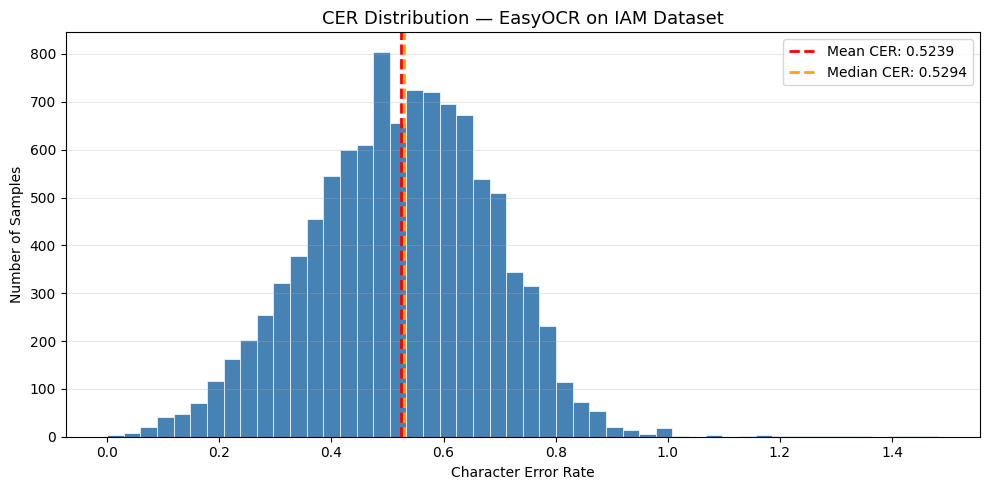

Mean CER   : 0.5239
Median CER : 0.5294
Std CER    : 0.1639
Samples with CER > 0.8 : 323
Samples with CER < 0.2 : 263


In [16]:
plt.figure(figsize=(10, 5))

plt.hist(df['cer'], bins=50, color='steelblue', 
         edgecolor='white', linewidth=0.5)

plt.axvline(df['cer'].mean(), color='red', 
            linestyle='--', linewidth=2,
            label=f"Mean CER: {df['cer'].mean():.4f}")

plt.axvline(df['cer'].median(), color='orange',
            linestyle='--', linewidth=2,
            label=f"Median CER: {df['cer'].median():.4f}")

plt.title('CER Distribution — EasyOCR on IAM Dataset', fontsize=13)
plt.xlabel('Character Error Rate')
plt.ylabel('Number of Samples')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/cer_distribution.png', dpi=150)
plt.show()

print(f"Mean CER   : {df['cer'].mean():.4f}")
print(f"Median CER : {df['cer'].median():.4f}")
print(f"Std CER    : {df['cer'].std():.4f}")
print(f"Samples with CER > 0.8 : {(df['cer'] > 0.8).sum()}")
print(f"Samples with CER < 0.2 : {(df['cer'] < 0.2).sum()}")

Most Deleted Characters

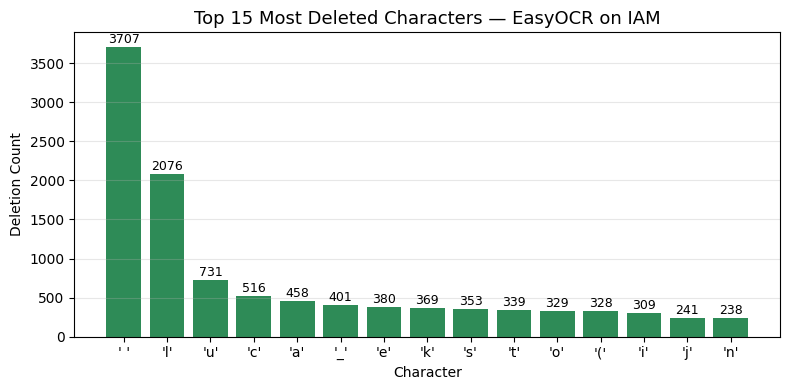


Top 10 deleted characters:
  ' ' deleted : 3707 times
  'l' deleted : 2076 times
  'u' deleted : 731 times
  'c' deleted : 516 times
  'a' deleted : 458 times
  '_' deleted : 401 times
  'e' deleted : 380 times
  'k' deleted : 369 times
  's' deleted : 353 times
  't' deleted : 339 times


In [18]:
from collections import Counter

del_counts = Counter(deletions)
top15_del  = del_counts.most_common(15)

chars  = [f"'{c}'" for c, _ in top15_del]
counts = [n for _, n in top15_del]

plt.figure(figsize=(8, 4))
bars = plt.bar(chars, counts, color='seagreen')

for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             str(val), ha='center', fontsize=9)

plt.title('Top 15 Most Deleted Characters — EasyOCR on IAM', fontsize=13)
plt.xlabel('Character')
plt.ylabel('Deletion Count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/top15_deletions.png', dpi=150)
plt.show()

print("\nTop 10 deleted characters:")
for char, count in top15_del[:10]:
    print(f"  '{char}' deleted : {count} times")

Confusion Matrix

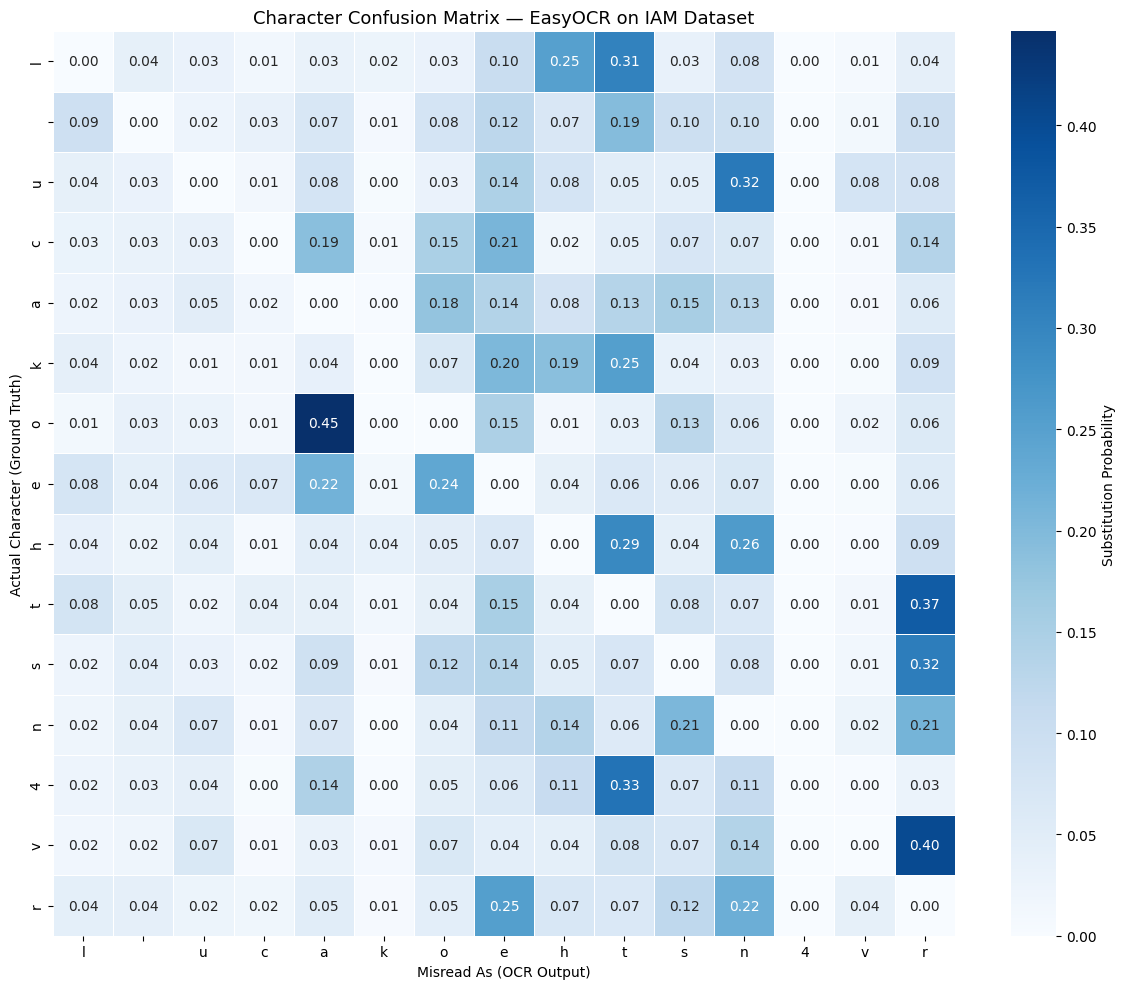

In [19]:
import string

# Focus on alphanumeric characters only
valid_chars = string.ascii_lowercase + string.digits + ' '

# Filter substitutions to valid chars only
filtered_subs = [(s, t) for s, t in substitutions 
                 if s in valid_chars and t in valid_chars]

# Build confusion matrix
top_chars = [c for c, _ in Counter([s for s, t in filtered_subs]).most_common(15)]

matrix = pd.DataFrame(0, index=top_chars, columns=top_chars)

for src, dst in filtered_subs:
    if src in top_chars and dst in top_chars:
        matrix.loc[src, dst] += 1

# Normalize by row
matrix_norm = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(matrix_norm, 
            annot=True, 
            fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            cbar_kws={'label': 'Substitution Probability'})

plt.title('Character Confusion Matrix — EasyOCR on IAM Dataset', fontsize=13)
plt.xlabel('Misread As (OCR Output)')
plt.ylabel('Actual Character (Ground Truth)')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix.png', dpi=150)
plt.show()

Error profile for noise injection


In [20]:
import json
from collections import Counter

# Complete counts
all_subs  = Counter(substitutions)
all_dels  = Counter(deletions)
all_ins   = Counter(insertions)

# Total errors for probability calculation
total_errors = len(substitutions) + len(deletions) + len(insertions)

error_profile = {
    'summary': {
        'total_samples'     : len(df),
        'mean_cer'          : float(df['cer'].mean()),
        'std_cer'           : float(df['cer'].std()),
        'median_cer'        : float(df['cer'].median()),
        'total_substitutions': len(substitutions),
        'total_deletions'   : len(deletions),
        'total_insertions'  : len(insertions),
        'total_errors'      : total_errors,
        'substitution_rate' : round(len(substitutions) / total_errors, 4),
        'deletion_rate'     : round(len(deletions) / total_errors, 4),
        'insertion_rate'    : round(len(insertions) / total_errors, 4)
    },
    'substitutions': {
        f"{s}→{t}": count 
        for (s, t), count in all_subs.most_common()
    },
    'deletions': {
        char: count 
        for char, count in all_dels.most_common()
    },
    'insertions': {
        char: count 
        for char, count in all_ins.most_common()
    }
}

with open('../outputs/error_profile.json', 'w') as f:
    json.dump(error_profile, f, indent=2)

print("Complete error profile saved")
print(f"Substitution pairs saved : {len(all_subs)}")
print(f"Deletion characters saved: {len(all_dels)}")
print(f"Insertion characters saved: {len(all_ins)}")

Complete error profile saved
Substitution pairs saved : 2299
Deletion characters saved: 69
Insertion characters saved: 52


Substituion Probability per character

In [21]:
# Build per-character substitution probability table
char_sub_probs = {}

for (src, dst), count in all_subs.items():
    if src not in char_sub_probs:
        char_sub_probs[src] = {}
    char_sub_probs[src][dst] = count

# Normalize to probabilities per source character
char_sub_probs_norm = {}
for src, targets in char_sub_probs.items():
    total = sum(targets.values())
    char_sub_probs_norm[src] = {
        dst: round(count/total, 4) 
        for dst, count in targets.items()
    }

# Add to error profile and resave
error_profile['substitution_probs'] = char_sub_probs_norm

with open('../outputs/error_profile.json', 'w') as f:
    json.dump(error_profile, f, indent=2)

print("Substitution probability table added")
print(f"Characters with substitution probs: {len(char_sub_probs_norm)}")

# Show example for character 'l'
print(f"\nExample — 'l' substitution probabilities:")
if 'l' in char_sub_probs_norm:
    top_l = sorted(char_sub_probs_norm['l'].items(), 
                   key=lambda x: x[1], reverse=True)[:5]
    for dst, prob in top_l:
        print(f"  l → {dst} : {prob}")

Substitution probability table added
Characters with substitution probs: 69

Example — 'l' substitution probabilities:
  l → t : 0.2276
  l → h : 0.1863
  l → e : 0.0778
  l → i : 0.0631
  l → n : 0.0612


Word Level Errors

In [23]:
pip install jiwer

Defaulting to user installation because normal site-packages is not writeable

  Attempting uninstall: click

    Found existing installation: click 8.1.7

    Uninstalling click-8.1.7:

      Successfully uninstalled click-8.1.7

   ---------------------------------------- 0/2 [click]
   ---------------------------------------- 0/2 [click]
   ---------------------------------------- 0/2 [click]
   -------------------- ------------------- 1/2 [jiwer]
   -------------------- ------------------- 1/2 [jiwer]
   ---------------------------------------- 2/2 [jiwer]

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.2 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


WER FORMULA
WER = (Substitutions + Deletions + Insertions) / Total Words in Reference

In [26]:
from jiwer import wer

# Manual check on a few samples
for i in range(5):
    gt  = df['ground_truth'].iloc[i]
    ocr = df['ocr_output'].iloc[i]
    w   = wer(gt, ocr)
    
    print(f"Sample {i}")
    print(f"  GT  : {gt}")
    print(f"  OCR : {ocr}")
    print(f"  WER : {w:.4f}")
    print()

Sample 0
  GT  : put down a resolution on the subject
  OCR : Pux dusl 0 vejolubon O4 Llr _ >uQeak
  WER : 1.1429

Sample 1
  GT  : and he is to be backed by Mr. Will
  OCR : o40 Lq _ 6 80 Qq _ baolea 64 Ar. W ;u
  WER : 1.3333

Sample 2
  GT  : nominating any more Labour life Peers
  OCR : uowiuak;w3 a Llone_ Labaur life_ FeQjs
  WER : 1.0000

Sample 3
  GT  : M Ps tomorrow. Mr. Michael Foot has
  OCR : MP< doxorrolo Mv Aicuae ( Fo6 lalA
  WER : 1.0000

Sample 4
  GT  : Griffiths, M P for Manchester Exchange .
  OCR : G+cF 4 4 P Poc Maucuoales Exeliauqe_
  WER : 1.0000



In [24]:
from jiwer import wer

# Calculate WER for each sample
df['wer'] = df.apply(
    lambda row: wer(row['ground_truth'], row['ocr_output']), 
    axis=1
)

print(f"Mean WER   : {df['wer'].mean():.4f}")
print(f"Median WER : {df['wer'].median():.4f}")
print(f"Std WER    : {df['wer'].std():.4f}")
print(f"Samples with WER > 0.8 : {(df['wer'] > 0.8).sum()}")
print(f"Samples with WER < 0.2 : {(df['wer'] < 0.2).sum()}")

Mean WER   : 1.0153
Median WER : 1.0000
Std WER    : 0.2271
Samples with WER > 0.8 : 9163
Samples with WER < 0.2 : 5


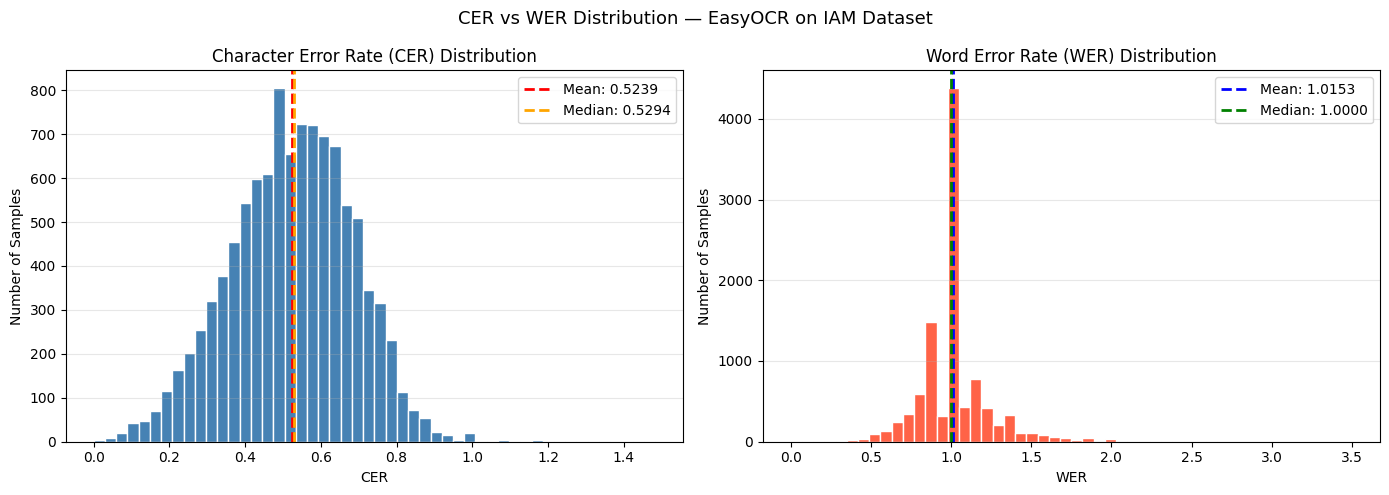

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CER distribution
axes[0].hist(df['cer'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['cer'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['cer'].mean():.4f}")
axes[0].axvline(df['cer'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median: {df['cer'].median():.4f}")
axes[0].set_title('Character Error Rate (CER) Distribution', fontsize=12)
axes[0].set_xlabel('CER')
axes[0].set_ylabel('Number of Samples')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# WER distribution
axes[1].hist(df['wer'], bins=50, color='tomato', edgecolor='white')
axes[1].axvline(df['wer'].mean(), color='blue', linestyle='--', linewidth=2,
                label=f"Mean: {df['wer'].mean():.4f}")
axes[1].axvline(df['wer'].median(), color='green', linestyle='--', linewidth=2,
                label=f"Median: {df['wer'].median():.4f}")
axes[1].set_title('Word Error Rate (WER) Distribution', fontsize=12)
axes[1].set_xlabel('WER')
axes[1].set_ylabel('Number of Samples')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('CER vs WER Distribution — EasyOCR on IAM Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/cer_vs_wer.png', dpi=150)
plt.show()

Position of Word level errors - beggining, middle or end


In [27]:
# Analyse where errors occur in words — beginning, middle or end
position_errors = {'beginning': 0, 'middle': 0, 'end': 0}

for _, row in df.iterrows():
    gt  = row['ground_truth'].lower()
    ocr = row['ocr_output'].lower()
    
    try:
        ops = editops(ocr, gt)
    except Exception:
        continue
    
    for op, src_idx, dst_idx in ops:
        # Find which word this character belongs to
        words = gt.split()
        pos = 0
        for word in words:
            word_start = gt.find(word, pos)
            word_end   = word_start + len(word)
            
            if word_start <= dst_idx < word_end:
                relative_pos = (dst_idx - word_start) / max(len(word), 1)
                
                if relative_pos < 0.25:
                    position_errors['beginning'] += 1
                elif relative_pos > 0.75:
                    position_errors['end'] += 1
                else:
                    position_errors['middle'] += 1
                break
            pos = word_end

print(position_errors)

{'beginning': 73916, 'middle': 109201, 'end': 21648}


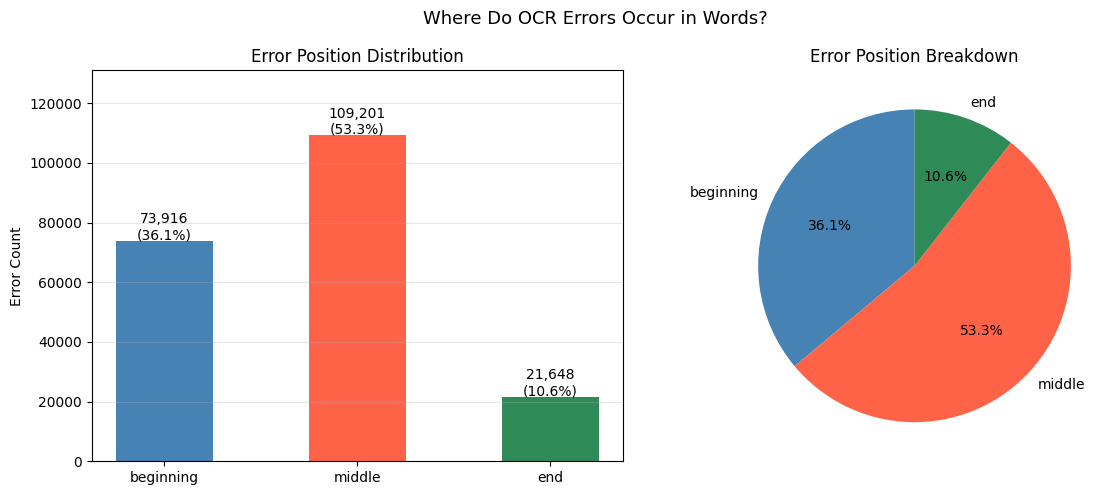

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
positions = list(position_errors.keys())
counts    = list(position_errors.values())
total     = sum(counts)

bars = axes[0].bar(positions, counts, 
                   color=['steelblue', 'tomato', 'seagreen'],
                   width=0.5)

for bar, val in zip(bars, counts):
    pct = val / total * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{val:,}\n({pct:.1f}%)',
                 ha='center', fontsize=10)

axes[0].set_title('Error Position Distribution', fontsize=12)
axes[0].set_ylabel('Error Count')
axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(counts, labels=positions, autopct='%1.1f%%',
            colors=['steelblue', 'tomato', 'seagreen'],
            startangle=90)
axes[1].set_title('Error Position Breakdown', fontsize=12)

plt.suptitle('Where Do OCR Errors Occur in Words?', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/wer_error_position.png', dpi=150)
plt.show()

In [30]:
import json

# Load existing profile
with open('../outputs/error_profile.json', 'r') as f:
    error_profile = json.load(f)

# Add WER stats
error_profile['summary']['mean_wer']              = float(df['wer'].mean())
error_profile['summary']['median_wer']            = float(df['wer'].median())
error_profile['summary']['std_wer']               = float(df['wer'].std())
error_profile['summary']['samples_wer_above_0_8'] = int((df['wer'] > 0.8).sum())
error_profile['summary']['samples_wer_below_0_2'] = int((df['wer'] < 0.2).sum())

# Add position analysis
total_pos = sum(position_errors.values())
error_profile['position_analysis'] = {
    'beginning' : position_errors['beginning'],
    'middle'    : position_errors['middle'],
    'end'       : position_errors['end'],
    'beginning_pct' : round(position_errors['beginning'] / total_pos, 4),
    'middle_pct'    : round(position_errors['middle'] / total_pos, 4),
    'end_pct'       : round(position_errors['end'] / total_pos, 4)
}

# Save
with open('../outputs/error_profile.json', 'w') as f:
    json.dump(error_profile, f, indent=2)

print("JSON updated with WER and position analysis")

JSON updated with WER and position analysis


In [31]:
# Extract word level CER
word_analysis = []

for _, row in df.iterrows():
    gt_words  = row['ground_truth'].lower().split()
    ocr_words = row['ocr_output'].lower().split()
    
    for i, gt_word in enumerate(gt_words):
        if i < len(ocr_words):
            ocr_word = ocr_words[i]
        else:
            ocr_word = ''
        
        try:
            word_cer = cer(gt_word, ocr_word)
        except Exception:
            continue
        
        word_analysis.append({
            'gt_word'    : gt_word,
            'ocr_word'   : ocr_word,
            'word_length': len(gt_word),
            'word_cer'   : round(word_cer, 4)
        })

df_words = pd.DataFrame(word_analysis)
print(f"Total words analysed: {len(df_words)}")
print(df_words.head())

Total words analysed: 0
Empty DataFrame
Columns: []
Index: []


In [32]:
print(df.columns.tolist())
print(len(df))
print(df.head(2))

['index', 'ground_truth', 'ocr_output', 'cer', 'wer']
10370
   index                          ground_truth  \
0      0  put down a resolution on the subject   
1      1    and he is to be backed by Mr. Will   

                              ocr_output     cer       wer  
0   Pux dusl 0 vejolubon O4 Llr _ >uQeak  0.6111  1.142857  
1  o40 Lq _ 6 80 Qq _ baolea 64 Ar. W ;u  0.6765  1.333333  


The issue was a namespace collision — a classic Python bug that's easy to miss.
When you import from jiwer import cer, Python creates a variable called cer in your notebook's memory that points to the jiwer function.
But your dataframe also has a column called cer — and when you later do df['cer'] or work with the dataframe, Python gets confused about which cer you mean in certain contexts.
Specifically when you wrote word_cer = cer(gt_word, ocr_word) inside the loop, Python was trying to call df['cer'] as a function instead of the jiwer function — which returns a pandas Series, not a callable, so it silently failed and produced an empty result.

In [33]:
from jiwer import cer as compute_cer

word_analysis = []

for _, row in df.iterrows():
    gt_words  = row['ground_truth'].lower().split()
    ocr_words = row['ocr_output'].lower().split()
    
    for i, gt_word in enumerate(gt_words):
        if i < len(ocr_words):
            ocr_word = ocr_words[i]
        else:
            ocr_word = ''
        
        if len(gt_word) == 0:
            continue
            
        try:
            word_cer = compute_cer(gt_word, ocr_word)
        except Exception:
            continue
        
        word_analysis.append({
            'gt_word'    : gt_word,
            'ocr_word'   : ocr_word,
            'word_length': len(gt_word),
            'word_cer'   : round(word_cer, 4)
        })

df_words = pd.DataFrame(word_analysis)
print(f"Total words analysed: {len(df_words)}")
print(df_words.head())

Total words analysed: 89937
      gt_word   ocr_word  word_length  word_cer
0         put        pux            3    0.3333
1        down       dusl            4    0.7500
2           a          0            1    1.0000
3  resolution  vejolubon           10    0.4000
4          on         o4            2    0.5000


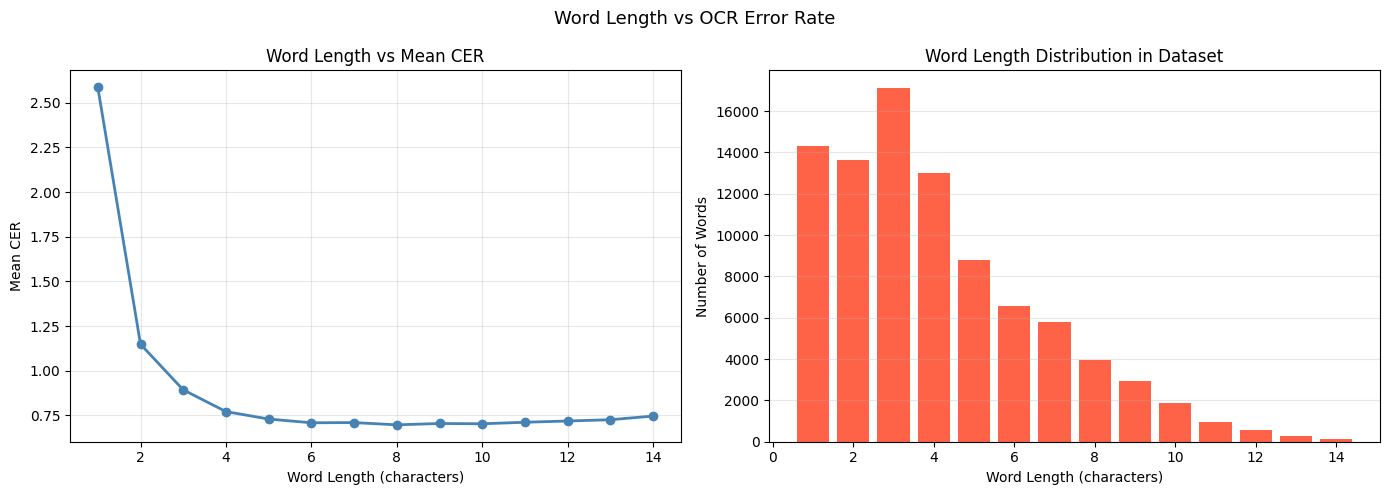


Word length vs Mean CER:
    word_length  mean_cer  count
0             1  2.587344  14317
1             2  1.148572  13623
2             3  0.893231  17121
3             4  0.771537  13001
4             5  0.729788   8782
5             6  0.708889   6560
6             7  0.709976   5775
7             8  0.697332   3954
8             9  0.704877   2917
9            10  0.703314   1871
10           11  0.711809    952
11           12  0.718842    575
12           13  0.725916    277
13           14  0.746505    133


In [34]:
# Group by word length and get mean CER
word_length_cer = df_words.groupby('word_length')['word_cer'].agg(['mean', 'count']).reset_index()
word_length_cer.columns = ['word_length', 'mean_cer', 'count']

# Filter to word lengths with enough samples
word_length_cer = word_length_cer[word_length_cer['count'] > 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — word length vs mean CER
axes[0].plot(word_length_cer['word_length'], 
             word_length_cer['mean_cer'], 
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Word Length vs Mean CER', fontsize=12)
axes[0].set_xlabel('Word Length (characters)')
axes[0].set_ylabel('Mean CER')
axes[0].grid(alpha=0.3)

# Plot 2 — word length distribution
axes[1].bar(word_length_cer['word_length'], 
            word_length_cer['count'],
            color='tomato')
axes[1].set_title('Word Length Distribution in Dataset', fontsize=12)
axes[1].set_xlabel('Word Length (characters)')
axes[1].set_ylabel('Number of Words')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Word Length vs OCR Error Rate', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/word_length_cer.png', dpi=150)
plt.show()

print("\nWord length vs Mean CER:")
print(word_length_cer[['word_length', 'mean_cer', 'count']].to_string())

In [36]:
# Add to error profile
with open('../outputs/error_profile.json', 'r') as f:
    error_profile = json.load(f)

error_profile['word_length_analysis'] = {
    str(row['word_length']): {
        'mean_cer': round(row['mean_cer'], 4),
        'count'   : int(row['count'])
    }
    for _, row in word_length_cer.iterrows()
}

with open('../outputs/error_profile.json', 'w') as f:
    json.dump(error_profile, f, indent=2)

# Save word level data
df_words.to_csv('../outputs/word_level_analysis.csv', index=False)

print("Word length analysis saved to JSON")
print("Word level data saved to CSV")

Word length analysis saved to JSON
Word level data saved to CSV


In [37]:
import string

punctuation_chars = set(string.punctuation)

punct_analysis = []

for _, row in df.iterrows():
    gt  = row['ground_truth'].lower()
    ocr = row['ocr_output'].lower()
    
    try:
        ops = editops(ocr, gt)
    except Exception:
        continue
    
    for op, src_idx, dst_idx in ops:
        if op == 'replace':
            dst_char = gt[dst_idx] if dst_idx < len(gt) else ''
            if dst_char in punctuation_chars:
                punct_analysis.append({
                    'type'    : 'substitution',
                    'char'    : dst_char,
                    'ocr_char': ocr[src_idx] if src_idx < len(ocr) else ''
                })
        elif op == 'delete':
            src_char = ocr[src_idx] if src_idx < len(ocr) else ''
            if src_char in punctuation_chars:
                punct_analysis.append({
                    'type': 'deletion',
                    'char': src_char,
                    'ocr_char': ''
                })
        elif op == 'insert':
            dst_char = gt[dst_idx] if dst_idx < len(gt) else ''
            if dst_char in punctuation_chars:
                punct_analysis.append({
                    'type'    : 'insertion',
                    'char'    : dst_char,
                    'ocr_char': ''
                })

df_punct = pd.DataFrame(punct_analysis)
print(f"Total punctuation errors : {len(df_punct)}")
print(f"\nError type breakdown:")
print(df_punct['type'].value_counts())
print(f"\nMost affected punctuation:")
print(df_punct['char'].value_counts().head(10))

Total punctuation errors : 14297

Error type breakdown:
type
substitution    5976
insertion       5696
deletion        2625
Name: count, dtype: int64

Most affected punctuation:
char
.    4246
,    3587
"    1426
'    1146
-    1027
_     401
(     375
&     205
)     199
/     185
Name: count, dtype: int64


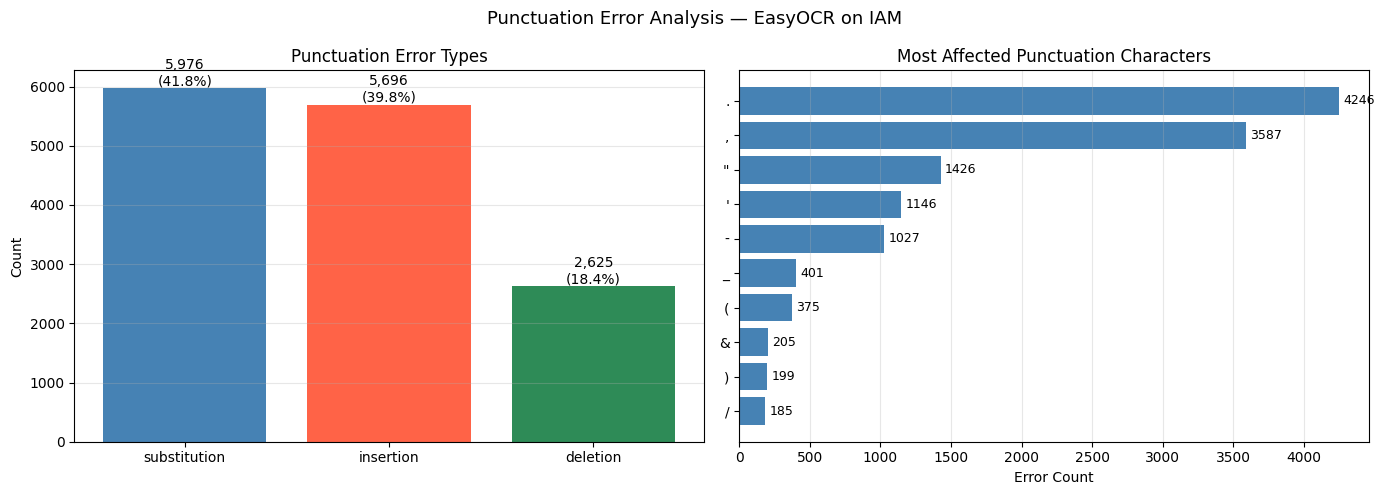

Punctuation analysis saved


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — punctuation error types
type_counts = df_punct['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['steelblue', 'tomato', 'seagreen'])
for bar, val in zip(axes[0].patches, type_counts.values):
    pct = val / len(df_punct) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)',
                 ha='center', fontsize=10)
axes[0].set_title('Punctuation Error Types', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — most affected punctuation
top_punct = df_punct['char'].value_counts().head(10)
axes[1].barh(top_punct.index[::-1], top_punct.values[::-1], color='steelblue')
for bar, val in zip(axes[1].patches, top_punct.values[::-1]):
    axes[1].text(bar.get_width() + 30,
                 bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[1].set_title('Most Affected Punctuation Characters', fontsize=12)
axes[1].set_xlabel('Error Count')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Punctuation Error Analysis — EasyOCR on IAM', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/punctuation_errors.png', dpi=150)
plt.show()

# Save to JSON
with open('../outputs/error_profile.json', 'r') as f:
    error_profile = json.load(f)

error_profile['punctuation_analysis'] = {
    'total_punct_errors'  : len(df_punct),
    'substitutions'       : int(type_counts.get('substitution', 0)),
    'insertions'          : int(type_counts.get('insertion', 0)),
    'deletions'           : int(type_counts.get('deletion', 0)),
    'most_affected'       : df_punct['char'].value_counts().head(10).to_dict()
}

with open('../outputs/error_profile.json', 'w') as f:
    json.dump(error_profile, f, indent=2)

print("Punctuation analysis saved")

In [39]:
import json

with open('../outputs/error_profile.json', 'r') as f:
    error_profile = json.load(f)

# Check what sections exist
print("Current sections in JSON:")
for key in error_profile.keys():
    print(f"  - {key}")

Current sections in JSON:
  - summary
  - substitutions
  - deletions
  - insertions
  - substitution_probs
  - position_analysis
  - word_length_analysis
  - punctuation_analysis
